# Python - map(), filter(), reduce()


<br>

## Intro

An iterable is a Python object that represents a collection of values that can be accessed one by one.

Examples of iterables:
- list
- range
- string
- dictionary (iterates over keys by default)
- tuple
- set


In this unit, we'll explore 3 functions that can be useful when working with iterables: map(), filter(), reduce()

<br>

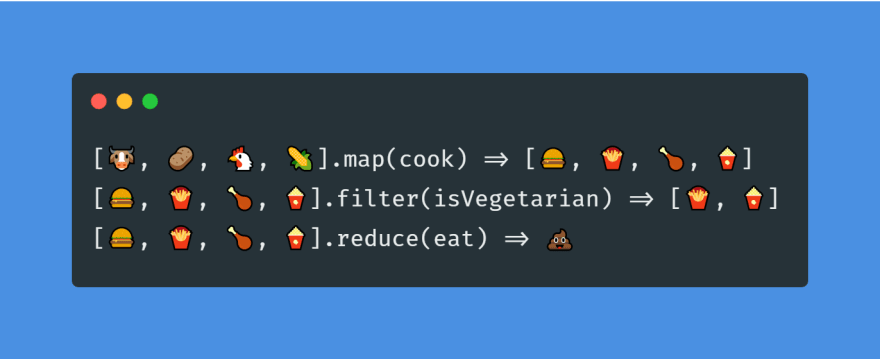

<br>

<br>

## `map()`


> map() in Python applies a function to every item of an iterable and returns an iterator with the results.




In [ ]:
#
# Example with a list of numbers
#

baskets = [5, 7, 10, 15, 3]

# Goal:  [10, 14, 20, 30, 6]



#
# Option A: let's use a for loop
#

points_A = []

for n in baskets:
    points_A.append(n * 2)

print(points_A)


#
# Option B: map() + a traditional function
#

def calc_double(amount):
    return amount * 2

points_B = map(calc_double, baskets)

print(list(points_B))  # note: `map()` returns an iterator. To see the results, you often convert it to a list, tuple, or another iterable.



#
# Option C: map() + a lambda function
#

points_C = map(lambda amount : amount * 2, baskets)

print(list(points_C))



#
# Option D: using a list comprehension
#

points_D = [amount * 2 for amount in baskets]

print(list(points_D))



[10, 14, 20, 30, 6]
[10, 14, 20, 30, 6]
[10, 14, 20, 30, 6]
[10, 14, 20, 30, 6]


<br>

💡 Tip: In Python, a list comprehension is often considered more readable than map(), especially for simple transformations.

<br>

In [ ]:
#
# Example with a list of dictionaries
#

users = [
    {"name": "alice", "age": 30},
    {"name": "bob", "age": 40},
    {"name": "charlie", "age": 50},
    {"name": "daniel", "age": 60},
    {"name": "elisabeth", "age": 70},
]

# Goal: [30, 40, 50, 60, 70]

ages = map(lambda user_dict : user_dict["age"], users)

print(list(ages))


[30, 40, 50, 60, 70]


<br>

⚠️ Important: `map()` returns an iterator:
- To see the results, you usually convert it to a list, tuple, or another iterable
- Once you iterate over it (e.g., convert it to a list), it gets "exhausted" and can't be reused

In [2]:
#
# Let's see how an iterator gets "exhausted"
#


baskets = [5, 7, 10, 15, 3]

points = map(lambda n : n * 2, baskets)

# if we run the line below, the iterator is exhausted...
print(list(points))

# ... and the for loop will not produce any output
for e in points:
    print(f"inside the for loop...", e)


#
# Solution:
#
# If we need to use it several times, we can convert it to a list, and store it in a variable
#
#
# points_B = map(lambda n : n * 2, baskets)
# points_list_B = list(points_B)
# 
# now we can use it multiple times...
# ...
# ...

[10, 14, 20, 30, 6]


<br>

## `filter()`


> filter() in Python applies a function to every item of an iterable and returns an iterator containing only the items for which the function returns True.




In [39]:
users = [
    {"name": "alice", "age": 30, "is_logged_in": False},
    {"name": "bob", "age": 40, "is_logged_in": False},
    {"name": "charlie", "age": 50, "is_logged_in": True},
    {"name": "daniel", "age": 60, "is_logged_in": True},
    {"name": "elisabeth", "age": 70, "is_logged_in": False},
    {"name": "frank", "age": 80, "is_logged_in": True},
]

# Goal: get a list with the users that are currently logged in

logged_in_users = filter(lambda user_dict : user_dict["is_logged_in"], users)

display(list(logged_in_users))



[{'name': 'charlie', 'age': 50, 'is_logged_in': True},
 {'name': 'daniel', 'age': 60, 'is_logged_in': True},
 {'name': 'frank', 'age': 80, 'is_logged_in': True}]

<br>


⚠️ Important: `filter()` returns an iterator:
- To see the results, you usually convert it to a list, tuple, or another iterable
- Once you iterate over it (e.g., convert it to a list), it gets "exhausted" and can't be reused

<br>

💡 Tip: In Python, a list comprehension is often considered more readable than filter(), especially for simple transformations.

<br>

## `reduce()`


> reduce() in Python (from the functools module) repeatedly applies a function to the items of an iterable, reducing them to a single accumulated value.

<br>

Syntax:

```py
from functools import reduce

reduce(function, iterable, initializer_optional)
```


<br>



In [49]:
# 
# Example 1: with a list of numbers
# 

from functools import reduce

baskets = [5, 7, 10, 15, 3]

# Goal: 40

def add_item(accumulator, next_item):
    return accumulator + next_item 

total = reduce(add_item, baskets)

# total = reduce(lambda accumulator, next_item : accumulator + next_item, baskets)

print(f"Final result: {total}")


Final result: 40


In [58]:
# 
# Example 2: with a list of dictionaries
# 

users = [
    {"name": "alice", "age": 30 },
    {"name": "bob", "age": 40 },
    {"name": "charlie", "age": 50 },
    {"name": "daniel", "age": 60 },
    {"name": "elisabeth", "age": 70 },
]

# Goal: find the total age from our users

def add_age(acc, next_item):
    return acc + next_item["age"]

total_age = reduce(add_age, users, 0)

print(total_age)

250


<br>

Notes:
- reduce() returns a single final value.
- This can be any type that you want (ie. it can be a number or a string, but also a list, a dictionary...)